In [91]:
%reload_ext autoreload
from functions_v2 import *

In [67]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from tqdm import tqdm

In [69]:
edges, n_vertices, edge_weights = load_graph("../summer-project/oregon1_010526.txt")

✓ Loaded: ../summer-project/oregon1_010526.txt
  Vertices : 65502
  Edges    : 23409
  Weighted : no



In [71]:
edges, n_vertices, edge_weights = load_graph("oregon1_010526.txt")

# remap node IDs to contiguous 0-indexed
all_nodes = sorted(set(v for e in edges for v in e))
node_map  = {old: new for new, old in enumerate(all_nodes)}
edges     = [(node_map[i], node_map[j]) for (i,j) in edges]
n_vertices = len(all_nodes)

print(f"Remapped vertices: {n_vertices}")  # should be 11174
print(f"Edges: {len(edges)}")              # should be 23409

✓ Loaded: oregon1_010526.txt
  Vertices : 65502
  Edges    : 23409
  Weighted : no

Remapped vertices: 11174
Edges: 23409


In [73]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 11174 x 11174
  Degree range: [1, 2389]
  Non-zeros in L: 57992



In [75]:
lambda_min = compute_lambda_min(L, D)

✓ lambda_min = 0.032899
  (eigenvalues found: [0.         0.03289937])


In [77]:
L_sigma  = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)



In [79]:
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.7850, 0.6575]



In [81]:
k = compute_permeability(u, edges, edge_weights)

In [83]:
degrees_arr = A.sum(axis=1)

# gamma_in = top 5 highest degree nodes (most connected brain regions — processing hubs)
# gamma_out = top 5 lowest degree nodes (least connected — peripheral regions)
degrees_arr = np.array(A.sum(axis=1)).flatten()  # convert sparse row sums to 1D array
gamma_in    = list(map(int, np.argsort(degrees_arr)[:20]))
gamma_out   = list(map(int, np.argsort(degrees_arr)[-5:]))

print(f"gamma_in  (hub regions)       : {gamma_in}")
print(f"gamma_out (peripheral regions): {gamma_out}")
print(f"  inlet degrees : {[int(degrees_arr[v]) for v in gamma_in]}")
print(f"  outlet degrees: {[int(degrees_arr[v]) for v in gamma_out]}")

gamma_in  (hub regions)       : [5586, 5963, 5962, 5961, 5959, 5957, 5951, 5950, 5945, 5967, 5944, 5934, 5933, 5931, 5928, 5923, 5919, 5909, 5906, 5943]
gamma_out (peripheral regions): [98, 906, 2284, 265, 190]
  inlet degrees : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  outlet degrees: [615, 884, 1042, 1334, 2389]


In [85]:
# weighted laplacian 
L_k = build_weighted_laplacian(edges, n_vertices, k)

In [87]:
p= solve_darcy_amg(L_k, n_vertices, gamma_in, gamma_out, p_in=1.0, p_out=0.0)

In [93]:
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=1000, use_amg=False)

Monte Carlo: 100%|██████████| 1000/1000 [48:00<00:00,  2.88s/sample, mean Q=17.0091] 


✓ Done — 1000 samples complete
  Mean Q : 17.009130
  Std Q  : 0.059612
  Var Q  : 0.003554



=== Monte Carlo Results ===
  Samples : 1000
  Mean Q  : 17.009130
  Std Q   : 0.059612
  Var Q   : 0.003554
  Min Q   : 16.799908
  Max Q   : 17.202640
Saved as uspowergrid_phase7.png


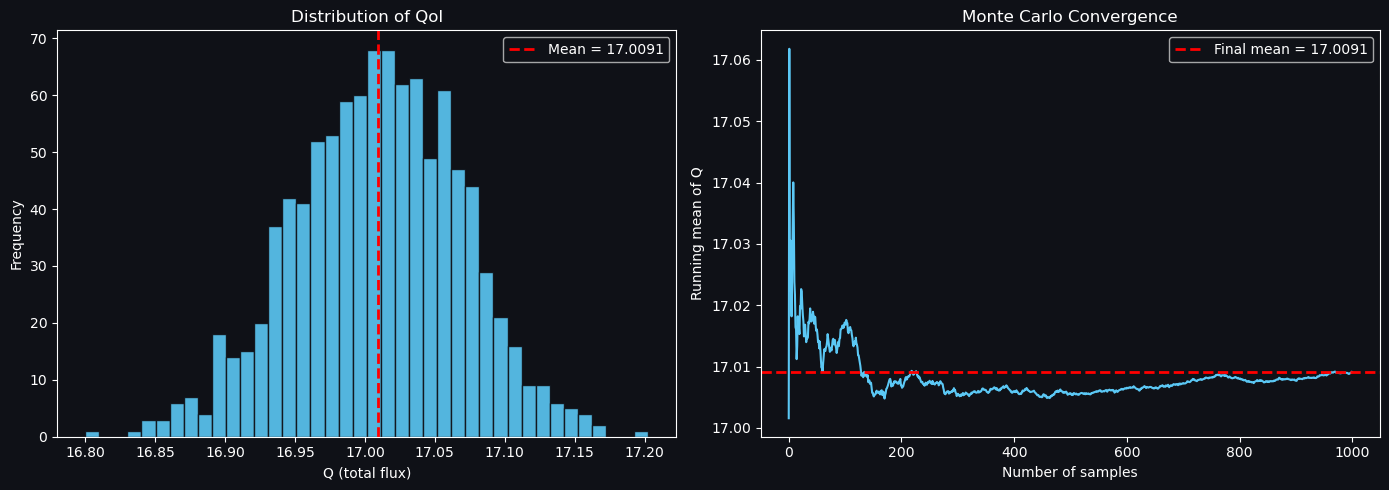

In [96]:
analyze_qoi(Q_samples, save_as="uspowergrid_phase7.png")

# Community detection

In [101]:
import networkx as nx

G_nx = nx.Graph()
G_nx.add_nodes_from(range(n_vertices))
G_nx.add_edges_from(edges)

print(f"Nodes: {G_nx.number_of_nodes()}")
print(f"Edges: {G_nx.number_of_edges()}")

Nodes: 11174
Edges: 23409


In [103]:
communities = list(nx.community.greedy_modularity_communities(G_nx))

# sort by size — largest communities first
communities = sorted(communities, key=len, reverse=True)

# use two largest communities on opposite ends
gamma_in  = list(communities[0])   # largest community
gamma_out = list(communities[1])   # second largest

print(f"Gamma_in  : {len(gamma_in)} vertices (Community 0)")
print(f"Gamma_out : {len(gamma_out)} vertices (Community 1)")

Exception ignored in: 'zmq.backend.cython.message.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq\\backend\\cython\\checkrc.pxd", line 13, in zmq.backend.cython.checkrc._check_rc
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
communities = list(nx.community.label_propagation_communities(G_nx))

print(f"Number of communities: {len(communities)}")
for i, c in enumerate(communities):
    print(f"  Community {i}: {len(c)} vertices, "
          f"avg degree = {np.mean([dict(G_nx.degree())[v] for v in c]):.2f}")

In [35]:
import time

w = np.random.randn(len(edges))
f = B @ w
u = cho_solve(cho_cache, lambda_min * f)

t1 = time.time()
k = compute_permeability(u, edges, edge_weights)
print(f"Phase 4 (permeability)  : {time.time()-t1:.3f}s")

t2 = time.time()
L_k = build_weighted_laplacian(edges, n_vertices, k)
print(f"Phase 5a (build L_k)    : {time.time()-t2:.3f}s")

t3 = time.time()
p = solve_darcy_amg(L_k, n_vertices, gamma_in, gamma_out)
print(f"Phase 5b (solve darcy)  : {time.time()-t3:.3f}s")

t4 = time.time()
Q = extract_qoi(p, k, edges, gamma_out)
print(f"Phase 6 (QoI)           : {time.time()-t4:.3f}s")

Phase 4 (permeability)  : 0.167s
Phase 5a (build L_k)    : 2.074s
Phase 5b (solve darcy)  : 1.614s
Phase 6 (QoI)           : 0.039s
